### Concepts shown in this demo notebook:

* Demonstrating how to use PCTrees to impute missing values / perform a kind of matrix factorization

In [2]:
import sys; sys.path.insert(0, "..")

In [3]:
from typing import Callable
import numpy as np
from numpy.typing import NDArray
import numpy.linalg as LA
import matplotlib.pyplot as plt
from random import randint
import random

from pctree.training import PCTreeTrainerOptions
from pctree.pruning import EfficientEncodingPruner
from pctree.linalg_utils import random_mask

from pctree.imputation import PCTreeImputerOptions, PCTImputer

import warnings
warnings.filterwarnings('ignore')

## Load Data

In [4]:
X = np.load("../data/mnist_train.npy").astype(np.float32)
X_mean = X.mean(axis=0)
X -= X_mean

## Remove 75% of values

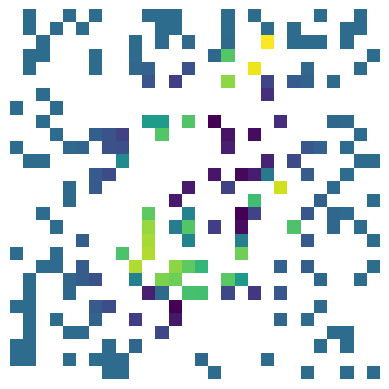

In [5]:
def random_remove(X: NDArray, factor: float):
    N, d = X.shape
    result = X.copy()
    for i in range(N):
        m = np.random.random(d)
        result[i, m < factor] = np.nan
    return result

X_missing = random_remove(X, 0.75)
fig, ax = plt.subplots()
ax.set_axis_off()
i=90
ax.imshow(X_missing[i].reshape(28, 28))

In [6]:
imputer_isvt_options = PCTreeImputerOptions(
    # we only do PCA interations, so these options dont really matter
    pct_training_options=PCTreeTrainerOptions(max_nodes=100, max_children=5,
        max_width=10,
        variance_capture_percent=0.997, 
        pruner=EfficientEncodingPruner(),
    ),
    n_pca_iters=20, # basically only do PCA Iters
    n_free_iters=0,
    n_reweight_iters=0
)
imputer_isvt = PCTImputer(imputer_isvt_options)
filled_isvt = imputer_isvt.fit_predict(X_missing)

In [7]:
imputer_options = PCTreeImputerOptions(
    pct_training_options=PCTreeTrainerOptions( 
        max_nodes=100, 
        max_children=5,
        max_width=10,
        variance_capture_percent=0.997, 
        pruner=EfficientEncodingPruner(),
    ),
    n_pca_iters=10,
    n_free_iters=5,
    n_reweight_iters=5
)
imputer = PCTImputer(imputer_options)
filled = imputer.fit_predict(X_missing, verbose=1)

Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
<<<<--<--<-<<-<
Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
-<-<-<<<--<---<<-----<
Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
-<-<<<<-<<----<----<
Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
--<-<-<-<---<-<<--<--<
Performing top-down partitioning to create initial PCT. 
Log Key: `-` is a node expanded by adding one additional child. `<` is a node expanded by spliting into two nodes. 
--<-<---<-<-<--<--<<--<


In [8]:
display_samp = random_mask(X.shape[0], 10)
filled_isvt_samp = filled_isvt[display_samp]
filled_samp = filled[display_samp]
og_samp = X[display_samp]
missing_samp = X_missing[display_samp]

In [9]:
import matplotlib as mpl
cmap = mpl.colormaps.get_cmap('viridis')  # viridis is the default colormap for imshow
cmap.set_bad(color='grey')

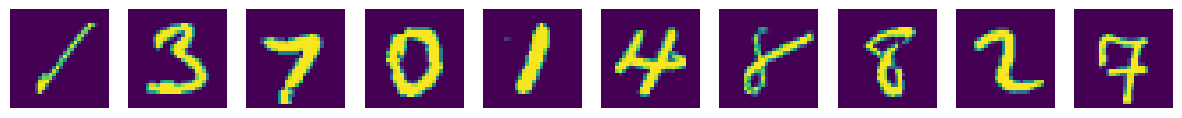

In [10]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for ax_i, ax in enumerate(axes):
    ax.set_axis_off()
    ax.imshow((og_samp[ax_i] + X_mean).reshape(28, 28), vmin=0, vmax=255)

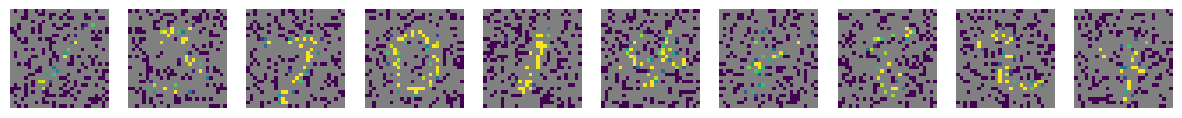

In [11]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for ax_i, ax in enumerate(axes):
    ax.set_axis_off()
    ax.imshow((missing_samp[ax_i] + X_mean).reshape(28, 28), vmin=0, vmax=255, cmap=cmap)

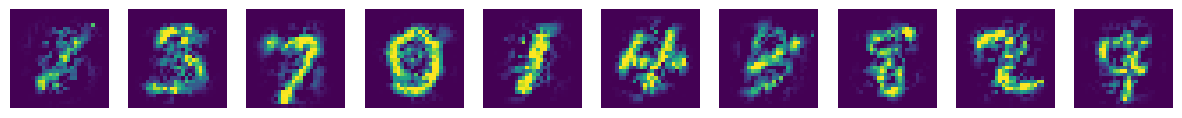

In [12]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for ax_i, ax in enumerate(axes):
    ax.set_axis_off()
    ax.imshow((filled_isvt_samp[ax_i] + X_mean).reshape(28, 28), vmin=0, vmax=255)

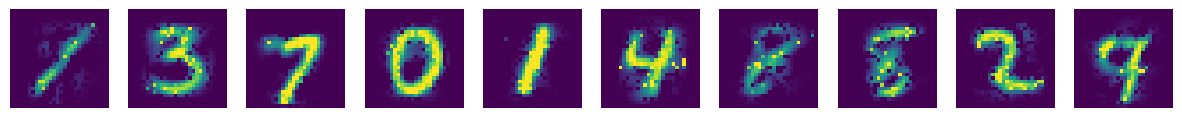

In [13]:
fig, axes = plt.subplots(1, 10, figsize=(15, 3))
for ax_i, ax in enumerate(axes):
    ax.set_axis_off()
    ax.imshow((filled_samp[ax_i] + X_mean).reshape(28, 28), vmin=0, vmax=255)